Loading data from C:\Users\NITRO V\Downloads\DAV exps\Social_Network_Ads.csv...

--- Results ---
Model Accuracy: 84.50%

Feature Weights:
  Age: 2.4401
  EstimatedSalary: 1.2204
  Bias: -1.1364


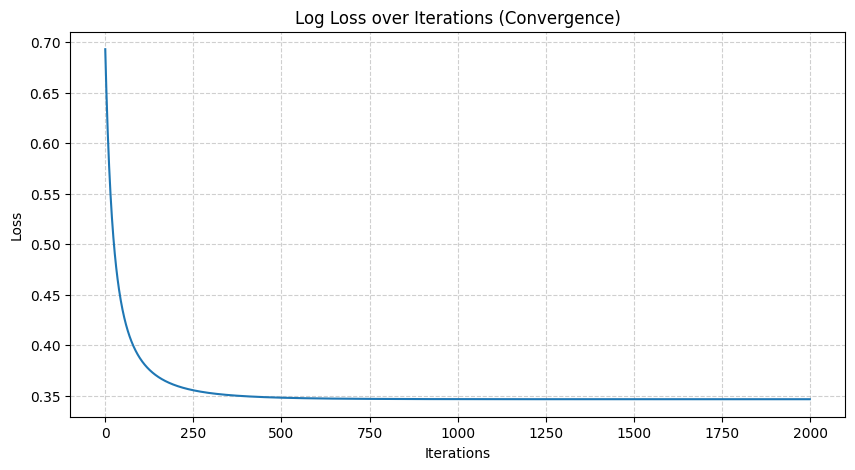

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class LogisticRegression:
    """
    A class to perform Logistic Regression using Gradient Descent.
    Used for binary classification.
    """
    
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Clip z to prevent overflow in exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(num_features)
        self.bias = 0
        self.loss_history = []

        for i in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            # Compute gradients
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Log loss for tracking convergence
            loss = -np.mean(y * np.log(y_predicted + 1e-15) + (1 - y) * np.log(1 - y_predicted + 1e-15))
            self.loss_history.append(loss)

    def predict_prob(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_prob(X)
        return np.array([1 if p >= threshold else 0 for p in probabilities])

    def accuracy(self, y_true, y_pred):
        return np.sum(y_true == y_pred) / len(y_true)

def load_any_csv(file_path, feature_cols, target_col):
    """
    Loads a CSV and prepares features and target for classification.
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)
    
    # 1. Clean data: Drop rows with missing values in relevant columns
    df = df.dropna(subset=feature_cols + [target_col])
    
    # 2. Extract X and y
    X = df[feature_cols].values
    y = df[target_col].values
    
    # Check if target is already binary. If not, you may need to map it.
    unique_vals = np.unique(y)
    if len(unique_vals) != 2:
        raise ValueError(f"Target column must have exactly 2 unique classes for Binary Logistic Regression. Found: {unique_vals}")

    # 3. Feature Scaling (Crucial for Gradient Descent)
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    # Avoid division by zero if a feature is constant
    X_std[X_std == 0] = 1
    X_scaled = (X - X_mean) / X_std
    
    return X_scaled, y

# --- CONFIGURATION SECTION ---
# Edit these variables to match your specific file and data structure
CONFIG = {
    "file_path": r"C:\Users\NITRO V\Downloads\DAV exps\Social_Network_Ads.csv",    # Change this to your file path
    "features": ["Age", "EstimatedSalary"],        # List of numeric feature column names
    "target": "Purchased",              # The binary target column name (must be 0 or 1)
    "learning_rate": 0.1,
    "iterations": 2000
}

if __name__ == "__main__":
    try:
        # 1. Load Data
        X, y = load_any_csv(
            CONFIG["file_path"], 
            CONFIG["features"], 
            CONFIG["target"]
        )

        # 2. Train Model
        model = LogisticRegression(
            learning_rate=CONFIG["learning_rate"], 
            iterations=CONFIG["iterations"]
        )
        model.fit(X, y)

        # 3. Evaluate
        y_pred = model.predict(X)
        acc = model.accuracy(y, y_pred)
        
        print("\n--- Results ---")
        print(f"Model Accuracy: {acc * 100:.2f}%")
        print("\nFeature Weights:")
        for name, weight in zip(CONFIG["features"], model.weights):
            print(f"  {name}: {weight:.4f}")
        print(f"  Bias: {model.bias:.4f}")

        # 4. Visualization
        plt.figure(figsize=(10, 5))
        
        # Plot Loss Curve
        plt.plot(model.loss_history)
        plt.title('Log Loss over Iterations (Convergence)')
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.show()

    except FileNotFoundError:
        print(f"Error: The file '{CONFIG['file_path']}' was not found.")
    except KeyError as e:
        print(f"Error: One of the columns was not found in the CSV: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")